<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/symbionts_count.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Data Preparation & Splitting into 4 Treatments
This block loads the data, ensures numeric formatting, isolates the HF vs NF morphs, and splits the dataset based exactly on your defined conditions.

In [36]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data
df = pd.read_csv('combine_spat_cell_count.csv')

# Clean and filter
df['Conc (Cell/polyp)'] = pd.to_numeric(df['Conc (Cell/polyp)'], errors='coerce')
df = df.dropna(subset=['Conc (Cell/polyp)'])
df = df[df['morph'].isin(['HF', 'NF'])].copy()

# Define the comprehensive sub-condition mapping and order
# This `plot_order` comes from zr5ZDPM7i1Tt (Global Plot Styling)
# We will use a slightly modified version for direct column values.
sub_condition_mapping_order = [
    'Ambient (23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

# Function to assign both the broad 'Condition' and the specific 'Sub_Condition'
def assign_full_conditions(row):
    # Determine Sub_Condition first for finer granularity
    if row['temp'] == 23 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Ambient', 'Ambient (23°C, pH 8.2, 10m)'
    elif row['temp'] == 27 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Temperature', '27°C'
    elif row['temp'] == 32 and row['pH'] == 8.2 and row['light'] == '10m':
        return 'Temperature', '32°C'
    elif row['pH'] == 7.8 and row['temp'] == 23 and row['light'] == '10m':
        return 'pH', 'pH 7.8'
    elif row['pH'] == 7.6 and row['temp'] == 23 and row['light'] == '10m':
        return 'pH', 'pH 7.6'
    elif row['light'] == '50m' and row['temp'] == 23 and row['pH'] == 8.2:
        return 'Light', '50m'
    elif row['light'] == 'Dark' and row['temp'] == 23 and row['pH'] == 8.2:
        return 'Light', 'Dark'
    return 'Exclude', 'Exclude'

df[['Condition', 'Sub_Condition']] = df.apply(lambda row: pd.Series(assign_full_conditions(row)), axis=1)

# Filter out excluded rows
df = df[df['Condition'] != 'Exclude'].copy()

# Enforce categorical order for Condition (for stats blocks)
condition_order_broad = ['Ambient', 'Temperature', 'pH', 'Light'] # Using a new name to avoid confusion with sub-condition order
df['Condition'] = pd.Categorical(df['Condition'], categories=condition_order_broad, ordered=True)

# Enforce categorical order for Sub_Condition (for plotting block)
df['Sub_Condition'] = pd.Categorical(df['Sub_Condition'], categories=sub_condition_mapping_order, ordered=True)

# =========================================================
# Area calculation with dynamic factor based on morph and treatment
# =========================================================
# Placeholder for your actual area factors (e.g., in mm^2)
# Structure: {('morph', 'Sub_Condition'): area_factor_value}
area_factors_per_morph_treatment = {
    ('HF', 'Ambient (23°C, pH 8.2, 10m)'): 2.566,
    ('NF', 'Ambient (23°C, pH 8.2, 10m)'): 2.151      ,
    ('HF', '27°C'): 2.943         ,
    ('NF', '27°C'): 2.989   ,
    ('HF', '32°C'):  2.745,
    ('NF', '32°C'): 3.255,
    ('HF', 'pH 7.8'): 1.658,
    ('NF', 'pH 7.8'): 2.374,
    ('HF', 'pH 7.6'): 2.447,
    ('NF', 'pH 7.6'): 2.860,
    ('HF', '50m'): 3.079,
    ('NF', '50m'): 3.889,
    ('HF', 'Dark'): 3.795,
    ('NF', 'Dark'): 2.722,
}

def get_area_factor(row):
    key = (row['morph'], row['Sub_Condition'])
    # Default to 1.0 if not found, or handle as appropriate for your data
    return area_factors_per_morph_treatment.get(key, 1.0)

df['Area_Factor'] = df.apply(get_area_factor, axis=1)
df['Cell_per_area_mm2'] = df['Conc (Cell/polyp)'] / df['Area_Factor']
# =========================================================

print("Data unified with both broad 'Condition' and granular 'Sub_Condition'.")
print("\nBroad Condition counts:")
print(df['Condition'].value_counts())
print("\nGranular Sub_Condition counts:")
print(df['Sub_Condition'].value_counts())

Data unified with both broad 'Condition' and granular 'Sub_Condition'.

Broad Condition counts:
Condition
Ambient        28
Temperature    22
Light          20
pH             14
Name: count, dtype: int64

Granular Sub_Condition counts:
Sub_Condition
Ambient (23°C, pH 8.2, 10m)    28
27°C                           15
50m                            12
Dark                            8
pH 7.8                          8
32°C                            7
pH 7.6                          6
Name: count, dtype: int64


# Block 2: Global Poster Styling
This block sets the exact font sizes and colors we discussed earlier, including the transparent background so your plots will seamlessly integrate into your poster.

In [37]:

import matplotlib.pyplot as plt
import seaborn as sns

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.2
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")

Global styling (with bold asterisks and reduced Y-ticks) initialized.


In [38]:
# --- BLOCK 3: STANDALONE NORMALITY CHECK ---

print("="*65)
print("SHAPIRO-WILK NORMALITY TEST REPORT")
print("="*65)

metrics_list = ['Conc (Cell/polyp)', 'Cell_per_area_mm2']
# Use sub_condition_mapping_order for detailed treatment analysis
conditions_list_granular = sub_condition_mapping_order

# Dictionary to store normality results for subsequent blocks
normality_results = {}

for metric in metrics_list:
    print(f"\nMetric: {metric}")
    print("-" * 40)
    normality_results[metric] = {}

    for sub_condition_label in conditions_list_granular:
        cond_df = df[df['Sub_Condition'] == sub_condition_label] # Filter by Sub_Condition
        normality_results[metric][sub_condition_label] = {} # Key by Sub_Condition

        # Skip if no data for this sub_condition
        if len(cond_df) == 0:
            print(f"[{sub_condition_label} - No Data] Insufficient data for normality test (< 3 samples)")
            normality_results[metric][sub_condition_label]['HF'] = False
            normality_results[metric][sub_condition_label]['NF'] = False
            continue

        for morph in ['HF', 'NF']:
            group_data = cond_df[cond_df['morph'] == morph][metric].dropna()
            n_samples = len(group_data)

            # Shapiro-Wilk requires at least 3 samples
            if n_samples >= 3:
                stat, p_val = stats.shapiro(group_data)
                is_normal = p_val > 0.05
                status = "✅ Normal (Parametric)" if is_normal else "❌ Non-Normal (Non-Parametric)"

                print(f"[{sub_condition_label} - {morph}] n = {n_samples} | W = {stat:.4f} | p-value = {p_val:.4f} -> {status}")
                normality_results[metric][sub_condition_label][morph] = is_normal
            else:
                print(f"[{sub_condition_label} - {morph}] n = {n_samples} | Insufficient data for normality test (< 3 samples)")
                normality_results[metric][sub_condition_label][morph] = False

print("\nNormality checking complete. Ready for Block 4 (Outlier Removal & Statistics Engine).")

SHAPIRO-WILK NORMALITY TEST REPORT

Metric: Conc (Cell/polyp)
----------------------------------------
[Ambient (23°C, pH 8.2, 10m) - HF] n = 17 | W = 0.9455 | p-value = 0.3889 -> ✅ Normal (Parametric)
[Ambient (23°C, pH 8.2, 10m) - NF] n = 11 | W = 0.9227 | p-value = 0.3414 -> ✅ Normal (Parametric)
[27°C - HF] n = 7 | W = 0.9686 | p-value = 0.8884 -> ✅ Normal (Parametric)
[27°C - NF] n = 8 | W = 0.9423 | p-value = 0.6337 -> ✅ Normal (Parametric)
[32°C - HF] n = 3 | W = 0.8322 | p-value = 0.1939 -> ✅ Normal (Parametric)
[32°C - NF] n = 4 | W = 0.8275 | p-value = 0.1613 -> ✅ Normal (Parametric)
[pH 7.8 - HF] n = 5 | W = 0.8800 | p-value = 0.3095 -> ✅ Normal (Parametric)
[pH 7.8 - NF] n = 3 | W = 0.9643 | p-value = 0.6369 -> ✅ Normal (Parametric)
[pH 7.6 - HF] n = 4 | W = 0.9015 | p-value = 0.4386 -> ✅ Normal (Parametric)
[pH 7.6 - NF] n = 2 | Insufficient data for normality test (< 3 samples)
 - HF] n = 7 | W = 0.8795 | p-value = 0.2244 -> ✅ Normal (Parametric)
 - NF] n = 5 | W = 0.9209

# Block 3: The Combined Cleaning & Stats Engine
To be scientifically rigorous, we must calculate outliers and statistics within each specific condition and morphotype. This block processes the master dataframe, returns a perfectly clean dataset, and saves the p-values so we know exactly where to draw the asterisks later.



In [39]:
# --- BLOCK 4: AUTOMATED OUTLIER REMOVAL & STATISTICAL ENGINE ---

# Enforce condition and metric tracking orders
# Use the granular sub_condition_mapping_order for detailed statistical analysis
condition_order_granular = sub_condition_mapping_order
metrics_list = ['Conc (Cell/polyp)', 'Cell_per_area_mm2']

# Global dictionaries to store cleaned data matrices and p-values for Block 5 plotting
cleaned_master_dfs = {metric: pd.DataFrame() for metric in metrics_list}
final_p_values = {metric: {} for metric in metrics_list}

print("="*80)
print("AUTOMATED OUTLIER SELECTION & ROBUST STATISTICAL COMPARISONS (HF vs NF)")
print("="*80)

for metric in metrics_list:
    print(f"\n\n##### ANALYSIS METRIC: {metric} #####")
    print("-" * 65)

    for sub_condition_label in condition_order_granular: # Loop through granular sub-conditions for stats
        # Isolate the current treatment slice
        cond_df = df[df['Sub_Condition'] == sub_condition_label] # Filter by Sub_Condition
        if len(cond_df) == 0:
            # If no data for this sub-condition, set p-value to 1.0 (NS) and skip
            final_p_values[metric][sub_condition_label] = 1.0
            print(f"[{sub_condition_label:<30}] Critical Warning: No data available for this sub-condition.")
            print("." * 65)
            continue

        # 1. OUTLIER REMOVAL (1.5x IQR calculated independently per morphotype)
        clean_cond_df = pd.DataFrame()
        outliers_removed_report = []

        for morph in ['HF', 'NF']:
            subset = cond_df[cond_df['morph'] == morph].copy()
            if len(subset) == 0:
                continue

            Q1 = subset[metric].quantile(0.25)
            Q3 = subset[metric].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Separate statistical outliers from valid data points
            outliers = subset[(subset[metric] < lower_bound) | (subset[metric] > upper_bound)]
            valid = subset[(subset[metric] >= lower_bound) & (subset[metric] <= upper_bound)]

            if len(outliers) > 0:
                outliers_removed_report.append(f"{morph} ({len(outliers)} point(s) dropped)")

            clean_cond_df = pd.concat([clean_cond_df, valid])

        # Append the curated data into our master tracking dataframe
        # Ensure Sub_Condition column is carried over
        cleaned_master_dfs[metric] = pd.concat([cleaned_master_dfs[metric], clean_cond_df])

        # Extract clean tracking arrays for localized testing
        hf_final = clean_cond_df[clean_cond_df['morph'] == 'HF'][metric].dropna()
        nf_final = clean_cond_df[clean_cond_df['morph'] == 'NF'][metric].dropna()

        # 2. AUTOMATED SELECTION FRAMEWORK
        if len(hf_final) >= 3 and len(nf_final) >= 3:
            # Re-test normality dynamically on the post-outlier cleaned subsets
            _, p_norm_hf = stats.shapiro(hf_final)
            _, p_norm_nf = stats.shapiro(nf_final)

            # Conditions match standard parametric rules (Both groups must be normal)
            is_normal = (p_norm_hf > 0.05) and (p_norm_nf > 0.05)

            if is_normal:
                test_name = "Independent T-test"
                stat, p_val = stats.ttest_ind(hf_final, nf_final, equal_var=True)
            else:
                test_name = "Mann-Whitney U test"
                stat, p_val = stats.mannwhitneyu(hf_final, nf_final, alternative='two-sided')

            # Cache the final p-value for the combined plotting block
            final_p_values[metric][sub_condition_label] = p_val # Store p-value based on granular sub-condition

            # Print localized, easily-scannable report lines
            outlier_str = ", ".join(outliers_removed_report) if outliers_removed_report else "None"
            print(f"[{sub_condition_label:<30}] Sample sizes: HF (n={len(hf_final)}), NF (n={len(nf_final)}) | Outliers: {outlier_str}")
            print(f"                               Normality Check: {'Passed' if is_normal else 'Failed'} (HF p={p_norm_hf:.4f}, NF p={p_norm_nf:.4f})")
            print(f"                               Deployed Framework: {test_name:<18} | Calculated p-value = {p_val:.4e}")
            print(f"                               Interpretation:     {'SIGNIFICANT STATISTICAL ADVANTAGE' if p_val < 0.05 else 'NO STATISTICAL DIFFERENCE (NS)'}")
            print("." * 65)
        else:
            final_p_values[metric][sub_condition_label] = 1.0 # Default to non-significant if not enough samples
            print(f"[{sub_condition_label:<30}] Critical Warning: Insufficient sample sizes remaining after IQR cleaning.")
            print("." * 65)

print("\nBlock 4 Execution Complete. Valid elements and p-value dictionaries are locked in memory.")
print("Ready for Block 5 (Generating the Combined Master Plots).")

AUTOMATED OUTLIER SELECTION & ROBUST STATISTICAL COMPARISONS (HF vs NF)


##### ANALYSIS METRIC: Conc (Cell/polyp) #####
-----------------------------------------------------------------
[Ambient (23°C, pH 8.2, 10m)   ] Sample sizes: HF (n=16), NF (n=11) | Outliers: HF (1 point(s) dropped)
                               Normality Check: Passed (HF p=0.3590, NF p=0.3414)
                               Deployed Framework: Independent T-test | Calculated p-value = 3.3675e-01
                               Interpretation:     NO STATISTICAL DIFFERENCE (NS)
.................................................................
[27°C                          ] Sample sizes: HF (n=7), NF (n=8) | Outliers: None
                               Normality Check: Passed (HF p=0.8884, NF p=0.6337)
                               Deployed Framework: Independent T-test | Calculated p-value = 9.9255e-01
                               Interpretation:     NO STATISTICAL DIFFERENCE (NS)
........................

# Block 5: Grouped Master Plot Generation

This block takes the outlier-free datasets and corresponding $p$-values calculated in Block 4, merges them into a single publication-ready canvas, handles coordinate-aligned significance positioning, cleans up the redundant legend markers, and exports high-fidelity Scalable Vector Graphics (.svg) files with a transparent background layer.

GENERATING TRANSPARENT VECTOR MASTER PLOTS FOR POSTER PANEL


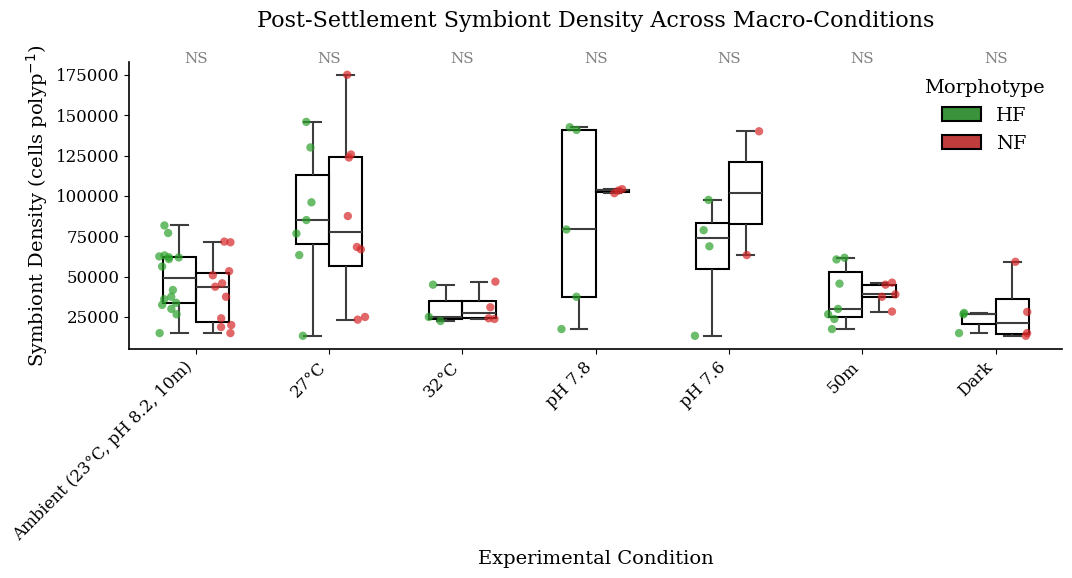

Successfully generated and exported: Combined_Master_Plot_Conc_Cell_polyp_granular.svg


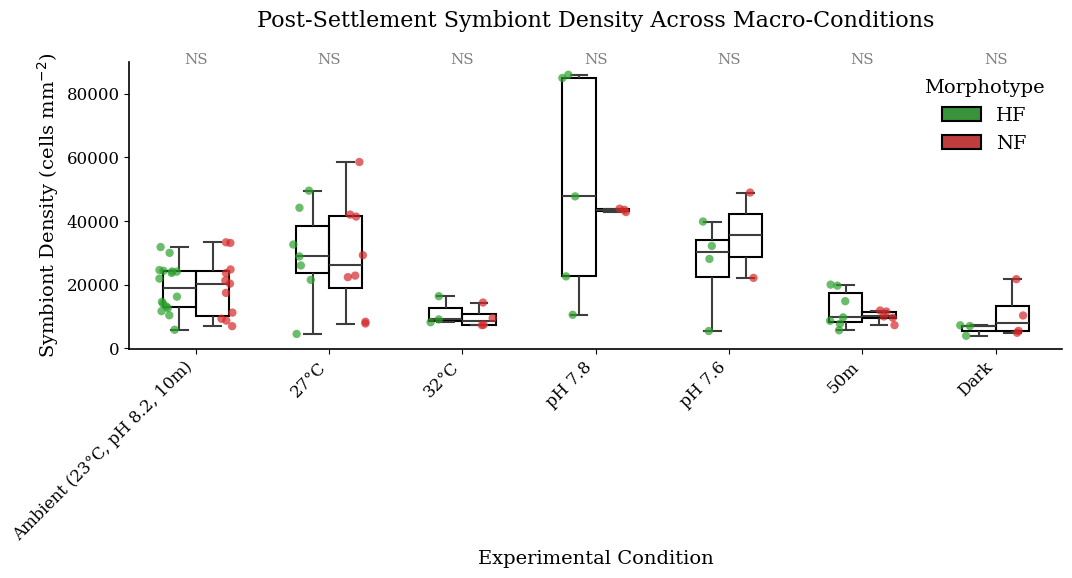

Successfully generated and exported: Combined_Master_Plot_Cell_per_area_mm2_granular.svg

PIPELINE COMPLETE: Your cell count assets are finalized and ready for layout!


In [40]:
# --- BLOCK 5: COMBINED MASTER PLOTS GENERATION ---

metrics_plotting_info = [
    ('Conc (Cell/polyp)', r"Symbiont Density (cells polyp$^{-1}$)"),
    ('Cell_per_area_mm2', r"Symbiont Density (cells mm$^{-2}$)")
]

print("="*80)
print("GENERATING TRANSPARENT VECTOR MASTER PLOTS FOR POSTER PANEL")
print("="*80)

# Define the order for Sub_Condition for plotting, this should match sub_condition_mapping_order in OTImZDjejdP0
sub_condition_plot_order = [
    'Ambient (23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

# The sub_to_broad_condition_map is no longer needed as p-values are now stored by sub_condition_label.

for metric, y_label in metrics_plotting_info:
    # Extract the clean dataset and specific p-values generated in Block 4
    plot_df = cleaned_master_dfs[metric]
    p_vals = final_p_values[metric] # p_vals are now keyed by granular 'Sub_Condition'

    if len(plot_df) == 0:
        print(f"Skipping plot for {metric}: No clean data available.")
        continue

    # Setup clear figure canvas with wide poster-optimized layout dimensions
    plt.figure(figsize=(11, 6))

    # 1. Base Structure: Hollow Grouped Boxplots (HF vs NF side-by-side)
    sns.boxplot(
        data=plot_df, x='Sub_Condition', y=metric, hue='morph', # Use Sub_Condition here
        hue_order=['HF', 'NF'], palette=variant_colors, width=0.5,
        showfliers=False, linewidth=1.5,
        boxprops={'facecolor': 'none', 'edgecolor': 'black'},
        order=sub_condition_plot_order # Ensure correct order on x-axis
    )

    # 2. Points Overlay: Grouped Jittered Points (dodge=True maps points exactly to boxes)
    sns.stripplot(
        data=plot_df, x='Sub_Condition', y=metric, hue='morph', # Use Sub_Condition here
        hue_order=['HF', 'NF'], palette=variant_colors, size=6,
        jitter=0.15, alpha=0.7, dodge=True, zorder=5,
        order=sub_condition_plot_order # Ensure correct order on x-axis
    )

    # 3. Dynamic Significance & 'NS' Alignment Engine
    max_y = plot_df[metric].max()
    for idx, sub_condition_label in enumerate(sub_condition_plot_order): # Iterate through sub-conditions
        p_value = p_vals.get(sub_condition_label, 1.0) # Fetch p-value directly using the sub_condition_label

        if p_value < 0.05:
            asterisks = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else "*")
            # Draw bold significance stars above the target category coordinate
            plt.text(idx, max_y * 1.03, asterisks, ha='center', va='bottom',
                     fontsize=24, fontweight='bold', color='black')
        else:
            # Place an elegant, non-intrusive 'NS' label for completeness
            plt.text(idx, max_y * 1.03, "NS", ha='center', va='bottom',
                     fontsize=11, fontweight='normal', color='gray')

    # Formatting and Styling Polish
    plt.title(f"Post-Settlement Symbiont Density Across Macro-Conditions", pad=25)
    plt.ylabel(y_label)
    plt.xlabel("Experimental Condition")

    # Rotate x-axis labels if they are long
    plt.xticks(rotation=45, ha='right') # Rotate and align right for readability

    # Fix the duplicated legends automatically triggered by overlaying plots
    handles, labels = plt.gca().get_legend_handles_labels()
    # Assuming the first two handles/labels correspond to 'HF' and 'NF' morphs
    plt.legend(handles[:2], labels[:2], title="Morphotype", frameon=False, loc='upper right')

    # Remove outer plot frames for clean presentation
    sns.despine()
    plt.tight_layout()

    # Export directly to vector format with transparent alpha background
    clean_metric_name = metric.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
    filename = f"Combined_Master_Plot_{clean_metric_name}_granular.svg" # Add '_granular' to filename
    plt.savefig(filename, format='svg', transparent=True)
    plt.show()

    print(f"Successfully generated and exported: {filename}")

print("\n" + "="*80)
print("PIPELINE COMPLETE: Your cell count assets are finalized and ready for layout!")
print("="*80)